# Optimising water delivery under constraints

The problem of water allocation can be mathematically described as a combinatorial optimisation problem. We model the system using a small number of water sources, including wells, desalination plants, or purchased water links. Each source is represented by a binary decision qubit indicating whether it is operational. Communities or demand regions can also be represented as qubits to track fulfillment of minimum water requirements. The objective is to maximise the total water delivered while respecting energy and sustainability constraints, which include limits on simultaneous plant operation, sustainable extraction thresholds, and minimum supply targets. These constraints are encoded as penalty terms in a QUBO or Hamiltonian formulation. This toy model illustrates how quantum optimisation can guide water distribution in resource-constrained environments, highlighting potential solutions for real-world sustainability challenges.

In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np

## Generating the graph

In [2]:
def graph(n=None):

    df = pd.read_csv(
        "cities_50largest.csv",
        sep=",",
        header=0,
        names=["city_id", "latitude", "longitude", "population_est"]
    )

    nodes = df[["city_id", "latitude", "longitude", "population_est"]]

    if n is not None:
        nodes = nodes[:n]

    random.seed(42)
    edge_prob = 0.5

    edges = []
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            if random.random() < edge_prob:
                u = int(nodes.iloc[i]["city_id"])
                v = int(nodes.iloc[j]["city_id"])
                weight = random.randint(1, 10)
                edges.append((u, v, weight))

    edges_df = pd.DataFrame(edges, columns=["from_city", "to_city", "weight"])

    return nodes, edges_df

In [3]:
def graph(n=None):

    df = pd.read_csv(
        "cities_50largest.csv",
        sep=",",
        header=0,
        names=["city_id", "latitude", "longitude", "population_est"]
    )
    nodes = df[["city_id", "latitude", "longitude", "population_est"]]

    if n is not None:
        nodes = nodes[:n]

    limit_distance = 0.4
    def _compute_distance(city_1, city_2):
        delta_long = city_1["longitude"] - city_2["longitude"]
        delta_lat = city_1["latitude"] - city_2["latitude"]
        dist = np.sqrt(delta_long**2 + delta_lat**2)
        return dist

    edges = [[0.0 for _ in range(len(nodes))] for _ in range(len(nodes))]
    for i in range(len(nodes)):
        edges[i][i] = 1.0
        for j in range(i + 1, len(nodes)):
            if _compute_distance(nodes.iloc[i], nodes.iloc[j]) < limit_distance:
                edges[i][j] = 1.0
                edges[j][i] = 1.0

    return nodes, edges

In [4]:
def plot_graph(nodes, edges):

    plt.figure(figsize=(8, 6))

    for i in range(len(edges)):
        for j in range(i + 1, len(edges[i])):
            if edges[i][j] > 0:
                x1, y1 = nodes.iloc[i][["longitude", "latitude"]]
                x2, y2 = nodes.iloc[j][["longitude", "latitude"]]
                plt.plot([x1, x2], [y1, y2], color="gray", alpha=0.5, linewidth=1)

    plt.scatter(
        nodes["longitude"],
        nodes["latitude"],
        s=nodes["population_est"] / 3000,
        color="tab:blue"
    )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

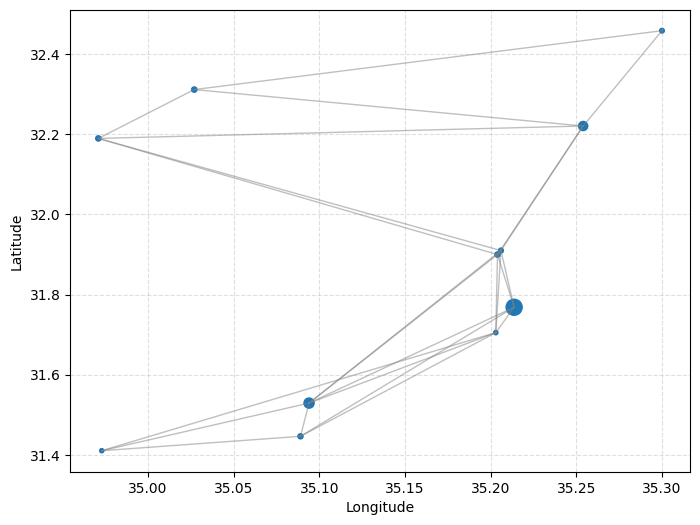

Degree: 7.0


In [5]:
nodes, edges = graph(11)
plot_graph(nodes, edges)

degrees = [sum(row) for row in edges]
degree = max(degrees)
print("Degree:", degree)

## Classical algorithm

In [6]:
def objective_function(Xs, W, S=3, mu=1.0):
    y = np.sum(np.dot(Xs, W))
    constraint = mu*(np.sum(Xs)-S)**2
    return y-constraint

## Quantum algorithm

In [8]:
import numpy as np
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals

In [9]:
# create a QUBO
qubo = QuadraticProgram()
qubo.binary_var("x")
qubo.binary_var("y")
qubo.binary_var("z")
qubo.minimize(linear=[1, -2, 3], quadratic={("x", "y"): 1, ("x", "z"): -1, ("y", "z"): 2})
print(qubo.prettyprint())

Problem name: 

Minimize
  x*y - x*z + 2*y*z + x - 2*y + 3*z

Subject to
  No constraints

  Binary variables (3)
    x y z

